# 🏆 Predicting Loan Payback - Playground Series S5E11
**Author:** Rishabh Kumar Kannaujiya  
**Date:** Nov 2025

## 1. Introduction
In this notebook, we tackle the **Playground Series Season 5, Episode 11** competition. The goal is to predict the probability of a borrower paying back a loan (Binary Classification).

**Approach:**
1. **EDA & Preprocessing:** Handling missing values, checking imbalance, and encoding categorical features.
2. **Modeling:** Training three Gradient Boosting giants: **XGBoost**, **LightGBM**, and **CatBoost**.
3. **Ensembling:** Combining predictions using a Weighted Average to maximize the **ROC AUC** score.

## 2. Setup and Data Loading

Here we will import the necessary libraries and load the training and testing datasets.

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

from lightgbm import LGBMClassifier
from lightgbm import early_stopping

from catboost import CatBoostClassifier

In [24]:
warnings.filterwarnings('ignore')

In [25]:
train_df = pd.read_csv('/kaggle/input/playground-series-s5e11/train.csv')
test_df = pd.read_csv('/kaggle/input/playground-series-s5e11/test.csv')
submission_df = pd.read_csv('/kaggle/input/playground-series-s5e11/sample_submission.csv')

In [26]:
train_df.shape

(593994, 13)

In [27]:
test_df.shape

(254569, 12)

In [28]:
train_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [29]:
train_df.columns.tolist()

['id',
 'annual_income',
 'debt_to_income_ratio',
 'credit_score',
 'loan_amount',
 'interest_rate',
 'gender',
 'marital_status',
 'education_level',
 'employment_status',
 'loan_purpose',
 'grade_subgrade',
 'loan_paid_back']

## 3. Exploratory Data Analysis (EDA)
We need to understand the distribution of the target variable and identify any missing data. We also drop the `id` column as it carries no predictive value.

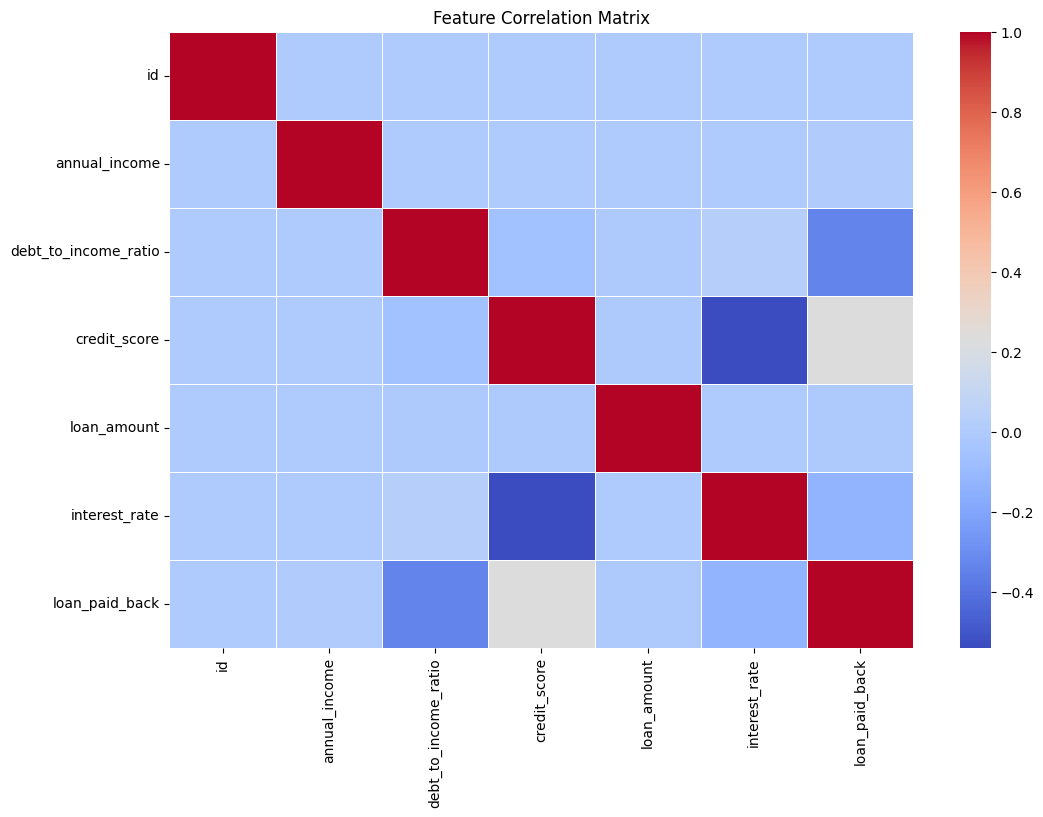

In [30]:
# Correlation Matrix of Numerical Features
plt.figure(figsize=(12, 8))

# Selecting only numerical columns for correlation
numerical_data = train_df.select_dtypes(include=[np.number])
corr = numerical_data.corr()

sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

In [31]:
target = 'loan_paid_back'
print('Target Distribution:')
train_df[target].value_counts(normalize=True)

Target Distribution:


loan_paid_back
1.0    0.79882
0.0    0.20118
Name: proportion, dtype: float64

In [32]:
print('Missing Values in Train:')
train_df.isnull().sum()

Missing Values in Train:


id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
loan_paid_back          0
dtype: int64

In [33]:
if 'id' in train_df.columns:
    train_df = train_df.drop(columns=['id'])
    test_df = test_df.drop(columns=['id'])

## 4. Advanced Feature Engineering

In [34]:
def create_features(df):

    # 1. Loan to Income Ratio (How heavy is the loan compared to their salary?)
    if 'loan_amount' in df.columns and 'annual_income' in df.columns:
        df['loan_to_income'] = df['loan_amount'] / (df['annual_income'] + 1)
    
    # 2. Monthly Burden (What % of monthly check goes to this loan?)
    if 'installment' in df.columns and 'annual_income' in df.columns:
        df['monthly_burden'] = df['installment'] / ((df['annual_income'] / 12) + 1)
        
    # 3. Total Interest Cost
    if 'loan_amount' in df.columns and 'interest_rate' in df.columns:
        df['total_interest_cost'] = df['loan_amount'] * df['interest_rate']

    # 4. Log Transform for Income (Helps with outliers)
    if 'annual_income' in df.columns:
        df['log_income'] = np.log1p(df['annual_income'])
        
    return df

# Apply to both Train and Test
print("Engineering new features...")
train_df = create_features(train_df)
test_df = create_features(test_df)
print("New features created.")
display(train_df.head())

Engineering new features...
New features created.


,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,loan_to_income,total_interest_cost,log_income
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,0.086091,34563.5014,10.287695
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,0.207748,59342.8520,10.003741
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,0.343073,165970.2640,10.811085
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,0.099926,75387.9280,10.754904
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,0.477864,124403.0303,10.146344


## 5. Preprocessing
### 5.1 Missing Values
We impute missing values to ensure our models run smoothly:
* **Numerical columns:** Filled with the **Median**.
* **Categorical columns:** Filled with the **Mode** (most frequent value).

In [35]:
cat_cols = [i for i in train_df.columns if train_df[i].dtype == 'object' and i != target]
num_cols = [i for i in train_df.columns if train_df[i].dtype != 'object' and i != target]

In [36]:
print('Categorical Columns:-', cat_cols, '\n\n', 'Number Columns:-', num_cols)

Categorical Columns:- ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade'] 

 Number Columns:- ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate', 'loan_to_income', 'total_interest_cost', 'log_income']


In [37]:
print('lenght of cat_cols:', len(cat_cols))
print('lenght of num_cols:', len(num_cols))

lenght of cat_cols: 6
lenght of num_cols: 8


### 5.2 Label Encoding
Machine learning models require numerical input. We will use **Label Encoding** to convert categorical text columns into unique integers.

In [38]:
from sklearn.preprocessing import OrdinalEncoder

# 1. Fill Missing Values Globally
for col in num_cols:
    median_val = train_df[col].median()
    train_df[col] = train_df[col].fillna(median_val)
    test_df[col] = test_df[col].fillna(median_val)

# 2. Encode the ENTIRE train_df (so X gets the numbers later)
ordinal_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# This updates train_df directly!
train_df[cat_cols] = ordinal_enc.fit_transform(train_df[cat_cols].astype(str))
test_df[cat_cols] = ordinal_enc.transform(test_df[cat_cols].astype(str))

# 3. Create X (Now it will contain numbers because train_df is encoded)
X = train_df.drop(columns=[target])
y = train_df[target]

# 4. Optional: Create a single split if you still want one for testing
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 6. Model Training
### 6.1 XGBoost

We start with **XGBoost**, a powerful gradient boosting library known for its performance and speed. We use an 80/20 train-validation split to monitor the **AUC Score**.

In [39]:
FOLDS = 5
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)

In [40]:
xgb_preds = np.zeros(len(test_df))
xgb_oof = np.zeros(len(X))

print("Training XGBoost on 5 Folds...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]
    
    xgb_model = XGBClassifier(
        n_estimators=2000,
        learning_rate=0.02,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        enable_categorical=False 
    )
    
    xgb_model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        eval_metric="auc",
        early_stopping_rounds=100,
        verbose=0 # Silent training
    )
    
    val_p = xgb_model.predict_proba(X_val_fold)[:, 1]
    xgb_oof[val_idx] = val_p
    xgb_preds += xgb_model.predict_proba(test_df)[:, 1] / FOLDS
    
    print(f"Fold {fold+1} XGB AUC: {roc_auc_score(y_val_fold, val_p):.5f}")

print(f"\nOverall XGBoost CV AUC: {roc_auc_score(y, xgb_oof):.5f}")

Training XGBoost on 5 Folds...
Fold 1 XGB AUC: 0.92259
Fold 2 XGB AUC: 0.92213
Fold 3 XGB AUC: 0.92029
Fold 4 XGB AUC: 0.92137
Fold 5 XGB AUC: 0.92080

Overall XGBoost CV AUC: 0.92143


### 6.2 LightGBM (K-Fold Cross Validation)

Now, we will train **LightGBM**. It is highly efficient and often captures different patterns than XGBoost, which makes it excellent for ensembling.

In [ ]:
oof_preds = np.zeros(len(X))
lgbm_preds = np.zeros(len(test_df))

print(f"Starting Training on {FOLDS} Folds with new features...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]
    
    
    lgbm_model = LGBMClassifier(
        n_estimators=3000,
        learning_rate=0.015,
        max_depth=8,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.6,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    lgbm_model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        eval_metric="auc",
        callbacks=[early_stopping(stopping_rounds=100)]
    )
    
    val_p = lgbm_model.predict_proba(X_val_fold)[:, 1]
    oof_preds[val_idx] = val_p
    
    lgbm_preds += lgbm_model.predict_proba(test_df)[:, 1] / FOLDS
    
    print(f"Fold {fold+1} AUC: {roc_auc_score(y_val_fold, val_p):.5f}")

cv_score = roc_auc_score(y, oof_preds)
print(f"\nOverall CV AUC Score: {cv_score:.5f}")

Starting Training on 5 Folds with new features...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2384]	valid_0's auc: 0.923415	valid_0's binary_logloss: 0.243293
Fold 1 AUC: 0.92341
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2204]	valid_0's auc: 0.922981	valid_0's binary_logloss: 0.24438
Fold 2 AUC: 0.92298
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[2310]	valid_0's auc: 0.92188	valid_0's binary_logloss: 0.245307


In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lgbm_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance.head(10), palette='viridis')
plt.title('Top 10 Most Important Features (LightGBM)')
plt.show()

### 6.3 CatBoost

Now, we will train **CatBoost**. This model is particularly robust and handles categorical relationships very well, often providing high stability.

In [ ]:
cat_preds = np.zeros(len(test_df))
cat_oof = np.zeros(len(X))

print("Training CatBoost on 5 Folds...")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train_fold, y_train_fold = X.iloc[train_idx], y.iloc[train_idx]
    X_val_fold, y_val_fold = X.iloc[val_idx], y.iloc[val_idx]
    
    cat_model = CatBoostClassifier(
        iterations=2000,
        learning_rate=0.02,
        depth=6,
        eval_metric='AUC',
        random_seed=42,
        verbose=0, # Silent
        early_stopping_rounds=100
    )
    
    cat_model.fit(X_train_fold, y_train_fold, eval_set=(X_val_fold, y_val_fold))
    
    val_p = cat_model.predict_proba(X_val_fold)[:, 1]
    cat_oof[val_idx] = val_p
    cat_preds += cat_model.predict_proba(test_df)[:, 1] / FOLDS
    
    print(f"Fold {fold+1} CatBoost AUC: {roc_auc_score(y_val_fold, val_p):.5f}")

print(f"\nOverall CatBoost CV AUC: {roc_auc_score(y, cat_oof):.5f}")

## 7. Ensembling & Submission
### 7.1 Weighted Ensemble

* To improve generalization and reduce overfitting, we will combine the predictions of all three models.
* Based on validation scores, we assign weights to each model to create the final model prediction.

In [ ]:
# Assuming equal weight: 33% XGB + 33% LGBM + 33% CatBoost
ensemble_oof_preds = (xgb_oof + oof_preds + cat_oof) / 3

In [ ]:
# Let's Check if the score improved here
ensemble_score = roc_auc_score(y, ensemble_oof_preds)

print(f"XGBoost OOF Score:   {roc_auc_score(y, xgb_oof):.5f}")
print(f"LightGBM OOF Score:  {roc_auc_score(y, oof_preds):.5f}")
print(f"CatBoost OOF Score:  {roc_auc_score(y, cat_oof):.5f}")
print("-" * 30)
print(f"Ensemble OOF Score:  {ensemble_score:.5f}") # (Likely the highest! if not then change the parameters in the weighted_val_preds)")

In [ ]:
# Creating weighted ensemble using Test predictions (for submission) and OOF (for scoring)
weighted_oof_preds = (oof_preds * 0.70) + (xgb_oof * 0.15) + (cat_oof * 0.15)
weighted_test_preds = (lgbm_preds * 0.70) + (xgb_preds * 0.15) + (cat_preds * 0.15)

In [ ]:
weighted_score = roc_auc_score(y, weighted_oof_preds)
print(f"Weighted Ensemble Score: {weighted_score:.5f}")

In [ ]:
submission_df[target] = weighted_test_preds
submission_df.to_csv('submission.csv', index=False)

print("Success! 'submission.csv' created.")